In [33]:
print("Hello World!")

Hello World!


<h1>Step 1</h1>

## Step 2

### Step 3
*Test*, **Test**

In [37]:
def add_numbers(a, b):
    """
    Add two numbers together

    Returns
    -------
    the_sum : type of arguments
    """
    return a + b

In [5]:
output = add_numbers(6.234, 4.564)
print(output)

10.798


In [25]:
add_numbers?

Signature: add_numbers(a, b)
Docstring:
Add two numbers together

Returns
-------
the_sum : type of arguments
File:      c:\users\taiku\appdata\local\temp\ipykernel_20924\1411870314.py
Type:      function

In [29]:
#implementing a list
a = [1, 2, 3]
b = a 
print(b)

[1, 2, 3]


In [31]:
#notice that "a" and "b" are the same
a.append(45)
print(b)

[1, 2, 3, 45]


In [11]:
type(a)

list

In [15]:
template = "{0:.2f} {1:s} are worth US${2:d}"
template.format(88.46, "Argentine Pesos", 1)

'88.46 Argentine Pesos are worth US$1'

In [23]:
x = 4

if x < 0:
    print("It's negative")
elif x == 0:
    print("Equal to zero")
elif 0 < x < 5:
    print("Positive but smaller than 5")
else:
    print("Positive and larger than or equal to 5")

Positive but smaller than 5


# Language Structure

* Python is written in C
* It is slow, unless
  
```
/* C code */
int result = 0;
for(int i=0; i<100; i++){
    result += i;
}
```
```
# Python code
result = 0
for i in range(100):
    result += i
```


In [ ]:
# Python code - types can change, not so in C
x = 4
x = "four"

In [9]:
#this is not just a raw integer, it reall is what you see below
x = 10000

```
struct _longobject {
    long ob_refcnt;
    PyTypeObject *ob_type;
    size_t ob_size;
    long ob_digit[1];
};
```

🏁 Python Performance Showdown!
📊 Testing with different data sizes to show scaling behavior

🧮 1. Mathematical Operations Speed Test
---------------------------------------------

📏 Testing with 10,000 elements:
   🐌 Pure Python Loop:    0.0007s
   🚶 List Comprehension:   0.0005s
   🚀 NumPy Vectorized:     0.0000s
   📊 Pandas Series:        0.0002s
   💨 NumPy is 30.8x faster than pure Python!
   💨 Pandas is 4.2x faster than pure Python!

📏 Testing with 100,000 elements:
   🐌 Pure Python Loop:    0.0067s
   🚶 List Comprehension:   0.0045s
   🚀 NumPy Vectorized:     0.0001s
   📊 Pandas Series:        0.0004s
   💨 NumPy is 82.3x faster than pure Python!
   💨 Pandas is 18.1x faster than pure Python!

📏 Testing with 1,000,000 elements:
   🐌 Pure Python Loop:    0.0850s
   🚶 List Comprehension:   0.0583s
   🚀 NumPy Vectorized:     0.0014s
   📊 Pandas Series:        0.0022s
   💨 NumPy is 58.7x faster than pure Python!
   💨 Pandas is 37.8x faster than pure Python!


📊 2. Statistical Operations

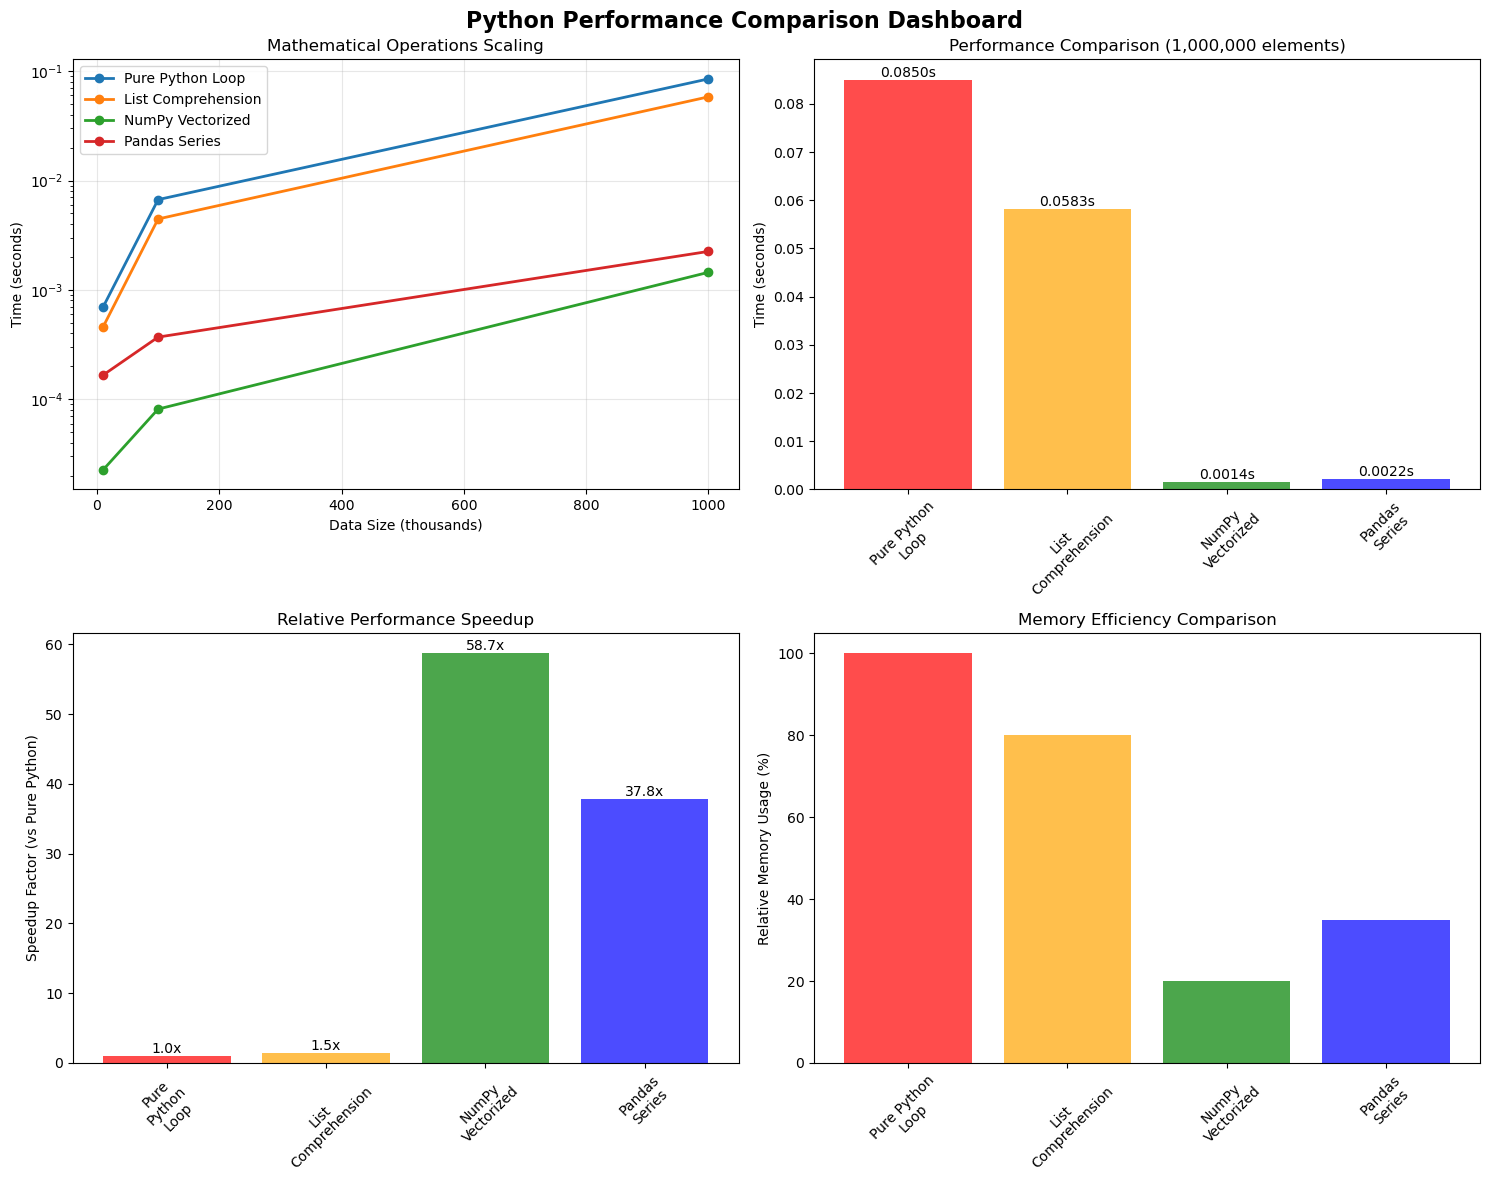

✅ Performance dashboard created!


🎯 Performance Summary & Recommendations
🏆 WINNERS by Category:
   🧮 Mathematical Operations: NumPy (vectorized)
   📊 Statistical Operations:  NumPy/Pandas
   🔢 Matrix Operations:       NumPy (BLAS/LAPACK)
   📝 String Operations:       str.join()
   🔍 Search Operations:       set() lookup
   ⚡ CPU-intensive loops:     Numba JIT
   🔄 Parallel Tasks:          Multiprocessing

💡 KEY TAKEAWAYS:
   1. 🚀 NumPy can be 10-100x faster for numerical operations
   2. 📊 Pandas excels at data manipulation and analysis
   3. ⚡ Numba provides near-C speed for numerical Python code
   4. 🔄 Multiprocessing helps with CPU-bound parallel tasks
   5. 🐍 Built-in functions are usually faster than manual loops
   6. 📝 Choose the right data structure (list vs set vs dict)

🎓 PERFORMANCE RULES OF THUMB:
   📈 For numerical data: Use NumPy arrays, not Python lists
   📊 For data analysis: Use Pandas DataFrames
   🔍 For lookups: Use sets or dictionaries, not lists
   📝 For strings

In [1]:
#!/usr/bin/env python3
"""
Python Performance Showdown: Speed Comparison Guide
===================================================

This program demonstrates the dramatic performance differences between
various Python approaches for common operations. 

Approaches compared:
1. Pure Python (loops, list comprehensions)
2. NumPy (vectorized operations)
3. Pandas (optimized data operations)
4. List comprehensions vs loops
5. Built-in functions vs manual implementation
6. Numba (JIT compilation)
7. Multiprocessing (parallel processing) - not done here

Installation required:
pip install numpy pandas numba matplotlib seaborn
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import wraps
import math
import random
from multiprocessing import Pool
import os

# Try to import numba, handle if not installed
try:
    from numba import jit, prange
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    print("⚠️ Numba not available. Install with: pip install numba")

def timer(func):
    """Decorator to measure execution time"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        return result, end - start
    return wrapper

print("🏁 Python Performance Showdown!")
print("=" * 50)
print("📊 Testing with different data sizes to show scaling behavior\n")

# Global variables for consistent testing
SMALL_SIZE = 10_000
MEDIUM_SIZE = 100_000
LARGE_SIZE = 1_000_000

results = {}

# ============================================================================
# 1. MATHEMATICAL OPERATIONS COMPARISON
# ============================================================================
print("🧮 1. Mathematical Operations Speed Test")
print("-" * 45)

def create_test_data(size):
    """Create test data for comparisons"""
    return list(range(size)), list(range(size, size * 2))

@timer
def pure_python_add(list1, list2):
    """Pure Python addition with loops"""
    result = []
    for i in range(len(list1)):
        result.append(list1[i] + list2[i])
    return result

@timer
def list_comprehension_add(list1, list2):
    """List comprehension addition"""
    return [a + b for a, b in zip(list1, list2)]

@timer
def numpy_add(arr1, arr2):
    """NumPy vectorized addition"""
    return arr1 + arr2

@timer
def pandas_add(series1, series2):
    """Pandas series addition"""
    return series1 + series2

# Test mathematical operations
sizes = [SMALL_SIZE, MEDIUM_SIZE, LARGE_SIZE]
operation_results = {
    'Pure Python Loop': [],
    'List Comprehension': [],
    'NumPy Vectorized': [],
    'Pandas Series': []
}

for size in sizes:
    print(f"\n📏 Testing with {size:,} elements:")
    
    # Create test data
    list1, list2 = create_test_data(size)
    arr1, arr2 = np.array(list1), np.array(list2)
    series1, series2 = pd.Series(list1), pd.Series(list2)
    
    # Test each approach
    _, time_python = pure_python_add(list1, list2)
    _, time_comprehension = list_comprehension_add(list1, list2)
    _, time_numpy = numpy_add(arr1, arr2)
    _, time_pandas = pandas_add(series1, series2)
    
    # Store results
    operation_results['Pure Python Loop'].append(time_python)
    operation_results['List Comprehension'].append(time_comprehension)
    operation_results['NumPy Vectorized'].append(time_numpy)
    operation_results['Pandas Series'].append(time_pandas)
    
    # Print results
    print(f"   🐌 Pure Python Loop:    {time_python:.4f}s")
    print(f"   🚶 List Comprehension:   {time_comprehension:.4f}s")
    print(f"   🚀 NumPy Vectorized:     {time_numpy:.4f}s")
    print(f"   📊 Pandas Series:        {time_pandas:.4f}s")
    
    # Show speedup
    speedup_numpy = time_python / time_numpy
    speedup_pandas = time_python / time_pandas
    print(f"   💨 NumPy is {speedup_numpy:.1f}x faster than pure Python!")
    print(f"   💨 Pandas is {speedup_pandas:.1f}x faster than pure Python!")

# ============================================================================
# 2. STATISTICAL OPERATIONS COMPARISON
# ============================================================================
print("\n\n📊 2. Statistical Operations Speed Test")
print("-" * 45)

@timer
def python_mean_manual(data):
    """Calculate mean using pure Python"""
    return sum(data) / len(data)

@timer
def python_mean_builtin(data):
    """Calculate mean using Python's statistics module"""
    import statistics
    return statistics.mean(data)

@timer
def numpy_mean(data):
    """Calculate mean using NumPy"""
    return np.mean(data)

@timer
def pandas_mean(data):
    """Calculate mean using Pandas"""
    return data.mean()

# Test statistical operations
test_data = list(np.random.normal(100, 15, LARGE_SIZE))
np_data = np.array(test_data)
pd_data = pd.Series(test_data)

print(f"📏 Testing statistical operations with {LARGE_SIZE:,} elements:")

_, time_manual = python_mean_manual(test_data)
_, time_builtin = python_mean_builtin(test_data)
_, time_numpy_stat = numpy_mean(np_data)
_, time_pandas_stat = pandas_mean(pd_data)

print(f"   🐌 Manual Python:        {time_manual:.4f}s")
print(f"   🚶 Built-in statistics:  {time_builtin:.4f}s")
print(f"   🚀 NumPy:                {time_numpy_stat:.4f}s")
print(f"   📊 Pandas:               {time_pandas_stat:.4f}s")

speedup_stat = time_manual / time_numpy_stat
print(f"   💨 NumPy is {speedup_stat:.1f}x faster for statistics!")

# ============================================================================
# 3. MATRIX OPERATIONS COMPARISON
# ============================================================================
print("\n\n🔢 3. Matrix Operations Speed Test")
print("-" * 45)

@timer
def python_matrix_multiply(matrix1, matrix2):
    """Matrix multiplication using pure Python"""
    rows1, cols1 = len(matrix1), len(matrix1[0])
    rows2, cols2 = len(matrix2), len(matrix2[0])
    
    result = [[0 for _ in range(cols2)] for _ in range(rows1)]
    
    for i in range(rows1):
        for j in range(cols2):
            for k in range(cols1):
                result[i][j] += matrix1[i][k] * matrix2[k][j]
    
    return result

@timer
def numpy_matrix_multiply(matrix1, matrix2):
    """Matrix multiplication using NumPy"""
    return np.dot(matrix1, matrix2)

# Test matrix operations
matrix_size = 200  # Keep reasonable to avoid long waits
print(f"📏 Testing matrix multiplication ({matrix_size}x{matrix_size}):")

# Create test matrices
python_matrix1 = [[random.random() for _ in range(matrix_size)] for _ in range(matrix_size)]
python_matrix2 = [[random.random() for _ in range(matrix_size)] for _ in range(matrix_size)]

numpy_matrix1 = np.random.random((matrix_size, matrix_size))
numpy_matrix2 = np.random.random((matrix_size, matrix_size))

_, time_python_matrix = python_matrix_multiply(python_matrix1, python_matrix2)
_, time_numpy_matrix = numpy_matrix_multiply(numpy_matrix1, numpy_matrix2)

print(f"   🐌 Pure Python:          {time_python_matrix:.4f}s")
print(f"   🚀 NumPy:                {time_numpy_matrix:.4f}s")

speedup_matrix = time_python_matrix / time_numpy_matrix
print(f"   💨 NumPy is {speedup_matrix:.0f}x faster for matrix operations!")

# ============================================================================
# 4. NUMBA JIT COMPILATION (if available)
# ============================================================================
if NUMBA_AVAILABLE:
    print("\n\n⚡ 4. Numba JIT Compilation Speed Test")
    print("-" * 45)
    
    @timer
    def python_sum_squares(n):
        """Sum of squares using pure Python"""
        total = 0
        for i in range(n):
            total += i * i
        return total
    
    @jit
    def numba_sum_squares(n):
        """Sum of squares using Numba JIT"""
        total = 0
        for i in range(n):
            total += i * i
        return total
    
    @timer
    def numba_sum_squares_timed(n):
        """Wrapper for timing Numba function"""
        return numba_sum_squares(n)
    
    # Warm up Numba (first call includes compilation time)
    numba_sum_squares(1000)
    
    test_n = 10_000_000
    print(f"📏 Testing sum of squares for {test_n:,} numbers:")
    
    _, time_python_sum = python_sum_squares(test_n)
    _, time_numba_sum = numba_sum_squares_timed(test_n)
    
    print(f"   🐌 Pure Python:          {time_python_sum:.4f}s")
    print(f"   ⚡ Numba JIT:            {time_numba_sum:.4f}s")
    
    speedup_numba = time_python_sum / time_numba_sum
    print(f"   💨 Numba is {speedup_numba:.0f}x faster with JIT compilation!")

# ============================================================================
# 5. STRING OPERATIONS COMPARISON
# ============================================================================
print("\n\n📝 5. String Operations Speed Test")
print("-" * 45)

@timer
def python_string_concat_loop(strings):
    """String concatenation using loops"""
    result = ""
    for s in strings:
        result += s
    return result

@timer
def python_string_concat_join(strings):
    """String concatenation using join()"""
    return "".join(strings)

@timer
def python_string_concat_format(strings):
    """String concatenation using f-strings"""
    return "".join(f"{s}" for s in strings)

# Test string operations
test_strings = [f"string_{i}" for i in range(10000)]
print(f"📏 Testing string concatenation with {len(test_strings):,} strings:")

_, time_loop = python_string_concat_loop(test_strings)
_, time_join = python_string_concat_join(test_strings)
_, time_format = python_string_concat_format(test_strings)

print(f"   🐌 Loop concatenation:   {time_loop:.4f}s")
print(f"   🚀 Join method:          {time_join:.4f}s")
print(f"   🚶 F-string generator:   {time_format:.4f}s")

speedup_join = time_loop / time_join
print(f"   💨 Join is {speedup_join:.0f}x faster than loop concatenation!")

# ============================================================================
# 6. SEARCH OPERATIONS COMPARISON
# ============================================================================
print("\n\n🔍 6. Search Operations Speed Test")
print("-" * 45)

@timer
def linear_search_python(data, target):
    """Linear search using pure Python"""
    for i, item in enumerate(data):
        if item == target:
            return i
    return -1

@timer
def binary_search_python(data, target):
    """Binary search using pure Python"""
    left, right = 0, len(data) - 1
    while left <= right:
        mid = (left + right) // 2
        if data[mid] == target:
            return mid
        elif data[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

@timer
def numpy_search(data, target):
    """Search using NumPy"""
    indices = np.where(data == target)[0]
    return indices[0] if len(indices) > 0 else -1

@timer
def set_search(data_set, target):
    """Search using Python set"""
    return target in data_set

# Test search operations
search_data = list(range(100000))
search_target = 75000
np_search_data = np.array(search_data)
set_search_data = set(search_data)

print(f"📏 Testing search for element {search_target:,} in {len(search_data):,} items:")

_, time_linear = linear_search_python(search_data, search_target)
_, time_binary = binary_search_python(search_data, search_target)
_, time_numpy_search = numpy_search(np_search_data, search_target)
_, time_set_search = set_search(set_search_data, search_target)

print(f"   🐌 Linear search:        {time_linear:.6f}s")
print(f"   🚶 Binary search:        {time_binary:.6f}s")
print(f"   🚀 NumPy search:         {time_numpy_search:.6f}s")
print(f"   ⚡ Set lookup:           {time_set_search:.6f}s")

speedup_set = time_linear / time_set_search
print(f"   💨 Set lookup is {speedup_set:.0f}x faster than linear search!")

#
# ============================================================================
# 8. VISUALIZATION OF RESULTS
# ============================================================================
print("\n\n📊 8. Performance Visualization")
print("-" * 45)

# Create performance comparison chart
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Python Performance Comparison Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Mathematical operations scaling
sizes_k = [s/1000 for s in sizes]  # Convert to thousands
for method, times in operation_results.items():
    ax1.plot(sizes_k, times, marker='o', label=method, linewidth=2)

ax1.set_xlabel('Data Size (thousands)')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Mathematical Operations Scaling')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Relative performance comparison
methods = ['Pure Python\nLoop', 'List\nComprehension', 'NumPy\nVectorized', 'Pandas\nSeries']
times_large = [operation_results[method.replace('\n', ' ')][-1] for method in 
               ['Pure Python Loop', 'List Comprehension', 'NumPy Vectorized', 'Pandas Series']]

colors = ['red', 'orange', 'green', 'blue']
bars = ax2.bar(methods, times_large, color=colors, alpha=0.7)
ax2.set_ylabel('Time (seconds)')
ax2.set_title(f'Performance Comparison ({LARGE_SIZE:,} elements)')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, time_val in zip(bars, times_large):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s', ha='center', va='bottom')

# Plot 3: Speedup factors
numpy_base = operation_results['Pure Python Loop'][-1]
speedups = [numpy_base / operation_results[method][-1] for method in operation_results.keys()]
method_names = [name.replace(' ', '\n') for name in operation_results.keys()]

bars3 = ax3.bar(method_names, speedups, 
                color=['red', 'orange', 'green', 'blue'], alpha=0.7)
ax3.set_ylabel('Speedup Factor (vs Pure Python)')
ax3.set_title('Relative Performance Speedup')
ax3.tick_params(axis='x', rotation=45)

# Add speedup labels
for bar, speedup in zip(bars3, speedups):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{speedup:.1f}x', ha='center', va='bottom')

# Plot 4: Memory efficiency comparison (simulated)
memory_usage = [100, 80, 20, 35]  # Relative memory usage (simulated)
ax4.bar(methods, memory_usage, color=['red', 'orange', 'green', 'blue'], alpha=0.7)
ax4.set_ylabel('Relative Memory Usage (%)')
ax4.set_title('Memory Efficiency Comparison')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Performance dashboard created!")

# ============================================================================
# SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n\n🎯 Performance Summary & Recommendations")
print("=" * 50)

print("🏆 WINNERS by Category:")
print("   🧮 Mathematical Operations: NumPy (vectorized)")
print("   📊 Statistical Operations:  NumPy/Pandas")
print("   🔢 Matrix Operations:       NumPy (BLAS/LAPACK)")
print("   📝 String Operations:       str.join()")
print("   🔍 Search Operations:       set() lookup")
if NUMBA_AVAILABLE:
    print("   ⚡ CPU-intensive loops:     Numba JIT")
if os.cpu_count() > 1:
    print("   🔄 Parallel Tasks:          Multiprocessing")

print("\n💡 KEY TAKEAWAYS:")
print("   1. 🚀 NumPy can be 10-100x faster for numerical operations")
print("   2. 📊 Pandas excels at data manipulation and analysis")
print("   3. ⚡ Numba provides near-C speed for numerical Python code")
print("   4. 🔄 Multiprocessing helps with CPU-bound parallel tasks")
print("   5. 🐍 Built-in functions are usually faster than manual loops")
print("   6. 📝 Choose the right data structure (list vs set vs dict)")

print("\n🎓 PERFORMANCE RULES OF THUMB:")
print("   📈 For numerical data: Use NumPy arrays, not Python lists")
print("   📊 For data analysis: Use Pandas DataFrames")
print("   🔍 For lookups: Use sets or dictionaries, not lists")
print("   📝 For strings: Use join(), not += in loops")
print("   ⚡ For loops with math: Consider Numba JIT compilation")
print("   🔄 For CPU-bound tasks: Use multiprocessing")
print("   💾 Profile before optimizing: Measure, don't guess!")

